##### 1. IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### 2. LOAD DATA

In [3]:
df = pd.read_csv("payment_fraud.csv")

In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          200 non-null    object 
 1   transaction_datetime    200 non-null    object 
 2   amount                  200 non-null    float64
 3   currency                200 non-null    object 
 4   customer_id             200 non-null    object 
 5   merchant_id             200 non-null    object 
 6   payment_method          200 non-null    object 
 7   device_id               126 non-null    object 
 8   ip_address              185 non-null    object 
 9   customer_country        200 non-null    object 
 10  merchant_country        200 non-null    object 
 11  is_international        200 non-null    bool   
 12  transaction_status      200 non-null    object 
 13  fraud_label             200 non-null    bool   
 14  fraud_reason            54 non-null     ob

##### 3. DATA CLEANING

In [5]:
df['transaction_datetime'] = pd.to_datetime(df['transaction_datetime'])

df['device_id'] = df['device_id'].fillna('missing')
df['fraud_label'] = df['fraud_label'].astype(int)
df['is_international'] = df['is_international'].astype(int)

##### 4. FEATURE ENGINEERING

In [6]:
df['hour'] = df['transaction_datetime'].dt.hour

df['amount_bucket'] = pd.cut(
    df['amount'],
    bins=[-1, 1000, 10000, 1e9],
    labels=['low', 'medium', 'high']
)

df['missing_device'] = np.where(df['device_id'] == 'missing', 1, 0)

##### 5. KPI CALCULATION

In [7]:
total_txn = len(df)
fraud_txn = df['fraud_label'].sum()
fraud_rate = round(100 * fraud_txn / total_txn, 2)

print("Total Transactions:", total_txn)
print("Fraud Transactions:", fraud_txn)
print("Fraud Rate:", fraud_rate, "%")

Total Transactions: 200
Fraud Transactions: 54
Fraud Rate: 27.0 %


##### 6. PAYMENT METHOD ANALYSIS

In [8]:
payment_fraud = (
    df.groupby('payment_method')['fraud_label']
    .mean()
    .sort_values(ascending=False) * 100
)

print("\nFraud Rate by Payment Method:\n", payment_fraud)


Fraud Rate by Payment Method:
 payment_method
crypto           95.238095
ewallet          45.161290
bank_transfer    31.818182
prepaid_card     23.529412
credit_card      10.769231
debit_card        4.545455
Name: fraud_label, dtype: float64


##### 8. BEHAVIORAL ANALYSIS

In [26]:
device_risk = df.groupby('missing_device')['fraud_label'].mean() * 100
print("\nFraud by Device Availability:\n", device_risk)

status_risk = df.groupby('transaction_status')['fraud_label'].mean() * 100
print("\nFraud by Transaction Status:\n", status_risk)

intl_risk = df.groupby('is_international')['fraud_label'].mean() * 100
print("\nFraud by International Transactions:\n", intl_risk)


Fraud by Device Availability:
 missing_device
0    10.317460
1    55.405405
Name: fraud_label, dtype: float64

Fraud by Transaction Status:
 transaction_status
completed     9.375000
failed       88.888889
pending       4.000000
reversed     81.818182
Name: fraud_label, dtype: float64

Fraud by International Transactions:
 is_international
0    11.702128
1    40.566038
Name: fraud_label, dtype: float64


##### 8. RISK SCORING MODEL

In [27]:
def calculate_risk(row):
    score = 0
    
    if row['amount'] > 50000:
        score += 2
    if row['is_international'] == 1:
        score += 2
    if row['entry_mode'] == 'online':
        score += 1
    if row['transaction_status'] == 'failed':
        score += 1
        
    return score

df['risk_score'] = df.apply(calculate_risk, axis=1)

def assign_bucket(score):
    if score >= 4:
        return 'high'
    elif score >= 2:
        return 'medium'
    else:
        return 'low'

df['risk_bucket'] = df['risk_score'].apply(assign_bucket)

risk_performance = df.groupby('risk_bucket')['fraud_label'].mean() * 100
print("\nRisk Bucket Performance:\n", risk_performance)


Risk Bucket Performance:
 risk_bucket
high      93.333333
low        2.380952
medium    27.906977
Name: fraud_label, dtype: float64


##### 9. HIGH-RISK SEGMENT ANALYSIS

In [28]:
high_value = df[df['amount'] > 50000]['fraud_label'].mean() * 100
print("\nHigh Value Fraud Rate:", round(high_value, 2), "%")

missing_pct = round(100 * df['missing_device'].sum() / len(df), 2)
print("Missing Device %:", missing_pct)


High Value Fraud Rate: 90.0 %
Missing Device %: 37.0


##### 10. CHARTS

##### Fraud Rate by Hour

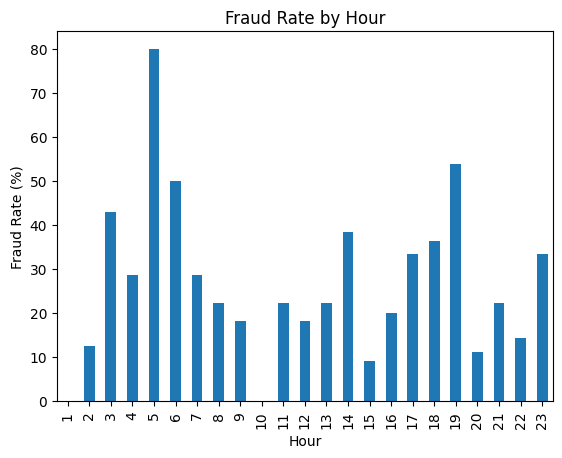

In [9]:
hourly_fraud = df.groupby('hour')['fraud_label'].mean() * 100

hourly_fraud.plot(kind='bar')
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.show()

##### Fraud Rate by Payment Method

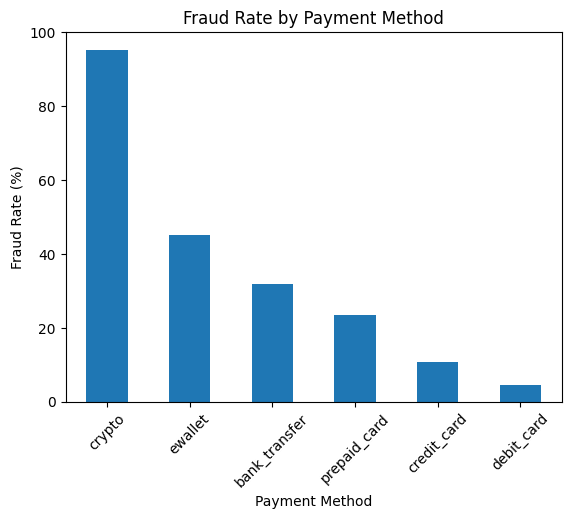

In [18]:
payment_fraud.plot(kind='bar')
plt.title("Fraud Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.show()

##### Risk Bucket Distribution

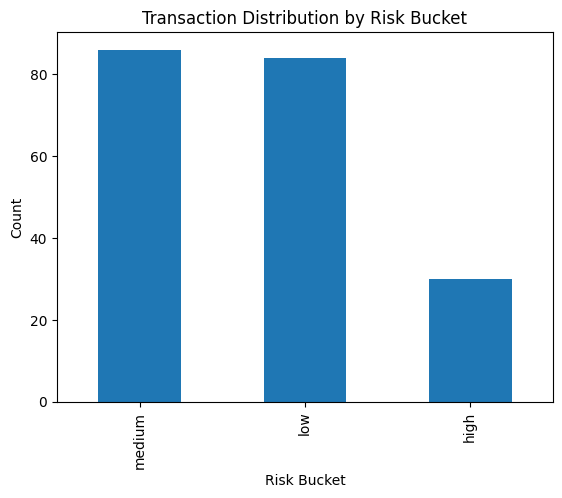

In [20]:
df['risk_bucket'].value_counts().plot(kind='bar')
plt.title("Transaction Distribution by Risk Bucket")
plt.xlabel("Risk Bucket")
plt.ylabel("Count")
plt.show()

##### Fraud Rate by Risk Bucket

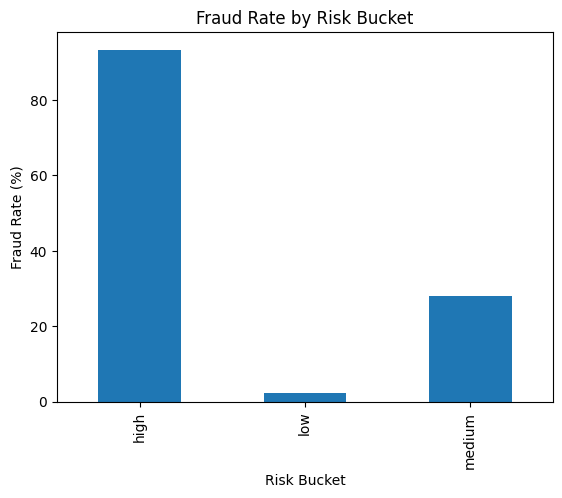

In [21]:
risk_performance.plot(kind='bar')
plt.title("Fraud Rate by Risk Bucket")
plt.xlabel("Risk Bucket")
plt.ylabel("Fraud Rate (%)")
plt.show()

##### Fraud by Transaction Status

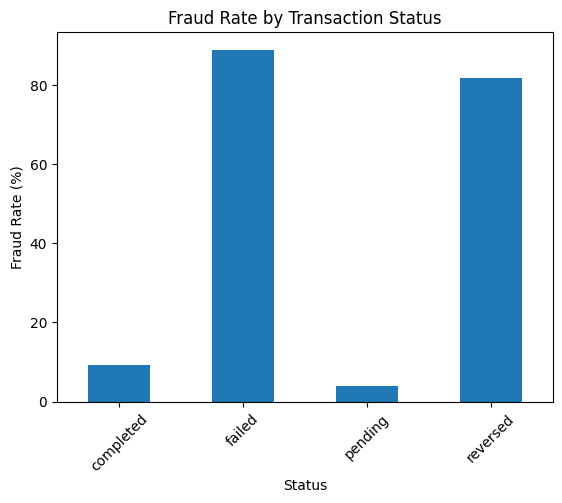

In [22]:
status_risk.plot(kind='bar')
plt.title("Fraud Rate by Transaction Status")
plt.xlabel("Status")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.show()

##### Amount vs Fraud (Distribution)

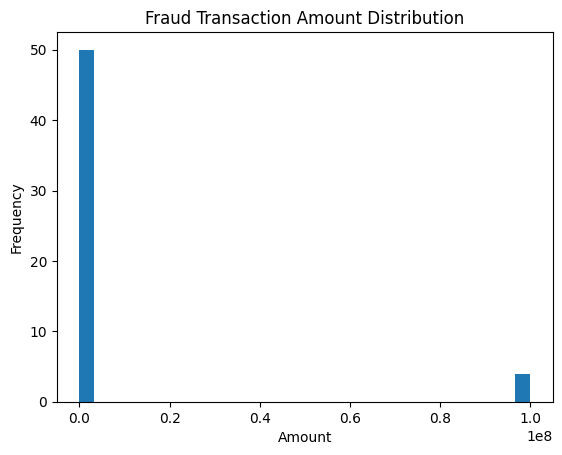

In [24]:
plt.hist(df[df['fraud_label']==1]['amount'], bins=30)
plt.title("Fraud Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()